In [1]:
import os

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
import pickle
import time

%matplotlib inline
import sys

import jax
from jax import config

config.update("jax_enable_x64", True)


import jax.numpy as jnp

os.getcwd()
sys.path.insert(0, os.path.abspath("."))
sys.path.append(os.path.abspath("../"))
sys.path.append(os.path.abspath("../../"))


import yancc

os.getcwd()

'/home/fouriest/Work/yancc/publications'

In [2]:
from yancc.solve import solve_dke
from yancc.species import LocalMaxwellian
from yancc.velocity_grids import (
    MaxwellSpeedGrid,
    UniformPitchAngleGrid,
)

In [3]:
sfincs_path = "./20251212-01-sfincs_for_yancc_benchmarks/20260528-01_sfincs_yancc_benchmark_NCSX_2species_Er_scan.txt"
data = np.loadtxt(sfincs_path, delimiter="\t", skiprows=1)

with open(sfincs_path) as f:
    headers = f.readlines()[0].split("\t")

headers = [h.lstrip().strip("\n") for h in headers]
for h in headers:
    print(h)

Er
FSABFlow_species1
FSABFlow_species2
particleFlux_vm_rHat_species1
particleFlux_vm_rHat_species2
heatFlux_vm_rHat_species1
heatFlux_vm_rHat_species2
particle_source_species1
energy_source_species1
particle_source_species2
energy_source_species2


In [4]:
sfincs_data = {head: dat for head, dat in zip(headers, data.T)}

In [5]:
rho = 0.5
# hydrogen ion charge and mass (same for electrons)
# n = 1.5e20 / m^3
# T = 0.8 keV
# dn/dr = -0.4e20 / m^4
# dT/dr = -2.0 keV/m
# full Fokker-Planck collision operator with full trajectories.
nt = 25
nz = 37
na = 61
nx = 7
# The collisionality was set using ln(Lambda) = 17.

In [6]:
field = yancc.field.Field.from_vmec("../tests/data/wout_NCSX.nc", rho, nt, nz)
pitchgrid = UniformPitchAngleGrid(na)
speedgrid = MaxwellSpeedGrid(nx)

In [10]:
species = [
    LocalMaxwellian(
        yancc.species.Electron,
        0.8e3,
        1.5e20,
        -2e3 * field.a_minor,
        -0.4e20 * field.a_minor,
    ),
    LocalMaxwellian(
        yancc.species.Hydrogen,
        0.8e3,
        1.5e20,
        -2e3 * field.a_minor,
        -0.4e20 * field.a_minor,
    ),
]

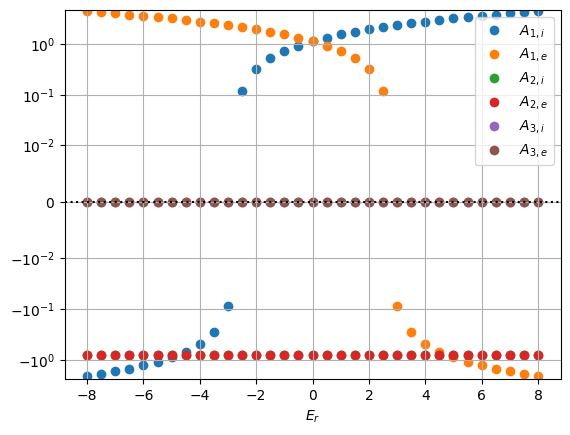

In [8]:
forces = np.array(
    [
        yancc.misc._dke_thermodynamic_forces(
            species, field, 1000 * Erho * field.a_minor, 0.0
        )
        for Erho in sfincs_data["Er"]
    ]
)
plt.scatter(sfincs_data["Er"], forces[:, 0, 0], label="$A_{1,i}$")
plt.scatter(sfincs_data["Er"], forces[:, 0, 1], label="$A_{1,e}$")
plt.scatter(sfincs_data["Er"], forces[:, 1, 0], label="$A_{2,i}$")
plt.scatter(sfincs_data["Er"], forces[:, 1, 1], label="$A_{2,e}$")
plt.scatter(sfincs_data["Er"], forces[:, 2, 0], label="$A_{3,i}$")
plt.scatter(sfincs_data["Er"], forces[:, 2, 1], label="$A_{3,e}$")
plt.xlabel("$E_r$")
plt.legend()
plt.axhline(0, c="k", ls=":")
plt.yscale("symlog", linthresh=1e-2)
plt.grid(True)

In [9]:
yancc_sols = []
yancc_infos = []
yancc_times = []

for Er in sfincs_data["Er"]:
    t0 = time.perf_counter()
    print("Er:", Er)
    sol, info = solve_dke(
        field,
        pitchgrid,
        speedgrid,
        species,
        Er * field.a_minor * 1000,  # Er in kV/m
        print_every=10,
        verbose=2,
        rtol=1e-7,
        coulomb_log=17,
    )
    sol = jax.block_until_ready(sol)
    t1 = time.perf_counter()
    del info["U"]
    del info["C"]
    yancc_sols.append(sol)
    yancc_infos.append(info)
    yancc_times.append(t1 - t0)
    print("TIME:", t1 - t0)

Er: -8.0
Field info (source: vmec):
    ρ         =  0.500              ι         = -4.689e-01
    <B>       =  1.538e+00 T        δ_B       =  4.857e-02
    Bmax/Bmin =  1.182e+00          f_trapped =  3.897e-01
    I         = -4.318e-03 T·m      G         =  2.325e+00 T·m
Species  0:  m= 5.45e-04 (mₚ)      q=-1.00e+00 (qₚ)
             n= 1.50e+20 (m⁻³)  a/Lₙ= 8.60e-02
             T= 8.00e+02 (eV)   a/Lᴛ= 8.07e-01  
             ν* (x=6.37e-02):  4.748e+03
             ν* (x=1.00e+00):  1.299e-01
             ν* (x=3.37e+00):  1.205e-03
Species  1:  m= 1.00e+00 (mₚ)      q= 1.00e+00 (qₚ)
             n= 1.50e+20 (m⁻³)  a/Lₙ= 8.60e-02
             T= 8.00e+02 (eV)   a/Lᴛ= 8.07e-01  
             ν* (x=6.37e-02):  2.373e+02
             ν* (x=1.00e+00):  5.158e-02
             ν* (x=3.37e+00):  6.254e-04
<E||B> :  0.00e+00 (V*T/m)
Eᵨ = -∂Φ /∂ρ: -2.58e+03 (V)
E* (x=1.0): [-3.101e-04 -1.329e-02 ] (per species)
Mₚ (x=1.0): [-3.095e-03 -1.326e-01 ] (per species)
A₁: [-2.102e+00  4.350e+0

In [10]:
data = {
    "yancc_sols": yancc_sols,
    "yancc_infos": yancc_infos,
    "yancc_times": np.array(yancc_times),
    "sfincs_data": sfincs_data,
}
with open("benchmark_ncsx_er_scan_two_species.pkl", "wb+") as f:
    pickle.dump(data, f)

In [7]:
with open("benchmark_ncsx_er_scan_two_species.pkl", "rb") as f:
    data = pickle.load(f)

In [8]:
yancc_fluxes = {}
yancc_fluxes["FSABFlow"] = np.array([sol.get("<V||B>") for sol in data["yancc_sols"]]).T
yancc_fluxes["particleFlux_vm_rN"] = np.array(
    [sol.get("<particle_flux>") for sol in data["yancc_sols"]]
).T
yancc_fluxes["heatFlux_vm_rN"] = np.array(
    [sol.get("<heat_flux>") for sol in data["yancc_sols"]]
).T
yancc_fluxes["J||B"] = np.array([sol.get("<J||B>") for sol in data["yancc_sols"]])
yancc_fluxes["J_rho"] = np.array([sol.get("J_rho") for sol in data["yancc_sols"]])

In [11]:
from scipy.constants import Boltzmann, elementary_charge, proton_mass

JOULE_PER_EV = jnp.array(11606 * Boltzmann)


Rbar = 1.0
mbar = 1.0 * proton_mass
Tbar = 1e3 * JOULE_PER_EV
nbar = 1e20
vbar = jnp.sqrt(2 * Tbar / mbar)
Bbar = 1.0

density0 = species[0].density
density1 = species[1].density

pfscale = Rbar / (nbar * vbar)
hfscale = Rbar / (nbar * vbar**3 * mbar)
vbscale0 = density0 / (vbar * Bbar * nbar)
vbscale1 = density1 / (vbar * Bbar * nbar)
jbscale = 1 / (elementary_charge * nbar * vbar * Bbar)
jrscale = Rbar / (elementary_charge * nbar * vbar)

In [12]:
from matplotlib import rcParams

matplotlib.rcdefaults()
rcParams["font.family"] = "DejaVu Serif"
rcParams["mathtext.fontset"] = "cm"
rcParams["font.size"] = 10
rcParams["figure.facecolor"] = (1, 1, 1, 1)
rcParams["figure.figsize"] = (6, 4)
rcParams["lines.markersize"] = 4
rcParams["xtick.labelsize"] = 10
rcParams["ytick.labelsize"] = 10

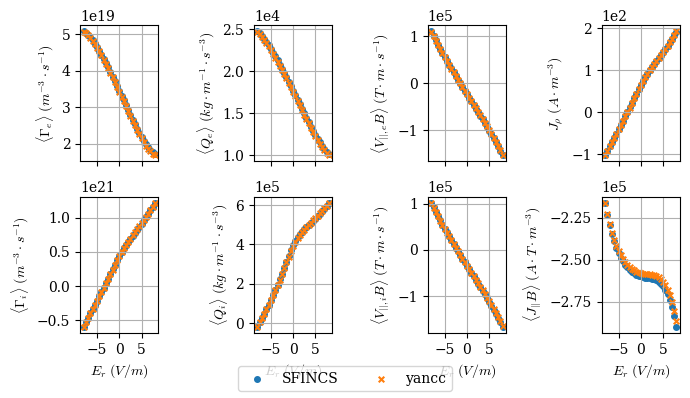

In [13]:
fig, ax = plt.subplots(2, 4, figsize=(7, 4), sharex=True)
ax[0, 0].scatter(
    sfincs_data["Er"],
    sfincs_data["particleFlux_vm_rHat_species1"] / pfscale / field.a_minor,
    marker="o",
)
ax[1, 0].scatter(
    sfincs_data["Er"],
    sfincs_data["particleFlux_vm_rHat_species2"] / pfscale / field.a_minor,
    marker="o",
)
ax[0, 1].scatter(
    sfincs_data["Er"],
    sfincs_data["heatFlux_vm_rHat_species1"] / hfscale / field.a_minor,
    marker="o",
)
ax[1, 1].scatter(
    sfincs_data["Er"],
    sfincs_data["heatFlux_vm_rHat_species2"] / hfscale / field.a_minor,
    marker="o",
)
ax[0, 2].scatter(
    sfincs_data["Er"], sfincs_data["FSABFlow_species1"] / vbscale0, marker="o"
)
ax[1, 2].scatter(
    sfincs_data["Er"], sfincs_data["FSABFlow_species2"] / vbscale1, marker="o"
)
ax[0, 3].scatter(
    sfincs_data["Er"],
    (
        sfincs_data["particleFlux_vm_rHat_species2"]
        - sfincs_data["particleFlux_vm_rHat_species1"]
    )
    / jrscale
    / field.a_minor,
    marker="o",
)
ax[1, 3].scatter(
    sfincs_data["Er"],
    (sfincs_data["FSABFlow_species2"] - sfincs_data["FSABFlow_species1"]) / jbscale,
    marker="o",
    label="SFINCS",
)


ax[0, 0].scatter(sfincs_data["Er"], yancc_fluxes["particleFlux_vm_rN"][0], marker="x")
ax[1, 0].scatter(sfincs_data["Er"], yancc_fluxes["particleFlux_vm_rN"][1], marker="x")
ax[0, 1].scatter(sfincs_data["Er"], yancc_fluxes["heatFlux_vm_rN"][0], marker="x")
ax[1, 1].scatter(sfincs_data["Er"], yancc_fluxes["heatFlux_vm_rN"][1], marker="x")
ax[0, 2].scatter(sfincs_data["Er"], yancc_fluxes["FSABFlow"][0], marker="x")
ax[1, 2].scatter(sfincs_data["Er"], yancc_fluxes["FSABFlow"][1], marker="x")
ax[0, 3].scatter(sfincs_data["Er"], yancc_fluxes["J_rho"], marker="x")
ax[1, 3].scatter(sfincs_data["Er"], yancc_fluxes["J||B"], marker="x", label="yancc")
for i in range(2):
    for j in range(4):
        ax[i, j].grid(True)
        ax[i, j].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
        if i == 1:
            ax[i, j].set_xlabel("$E_r ~(V/m)$")

ax[0, 0].set_ylabel(r"$\langle \Gamma_e \rangle ~ (m^{-3} \cdot s^{-1})$")
ax[1, 0].set_ylabel(r"$\langle \Gamma_i \rangle ~ (m^{-3} \cdot s^{-1})$")
ax[0, 1].set_ylabel(r"$\langle Q_e \rangle ~ (kg \cdot m^{-1} \cdot s^{-3})$")
ax[1, 1].set_ylabel(r"$\langle Q_i \rangle ~ (kg \cdot m^{-1} \cdot s^{-3})$")
ax[0, 2].set_ylabel(r"$\langle V_{||,e}B \rangle ~(T \cdot m \cdot s^{-1})$")
ax[1, 2].set_ylabel(r"$\langle V_{||,i}B \rangle ~(T \cdot m \cdot s^{-1})$")
ax[0, 3].set_ylabel(r"$J_\rho ~ (A \cdot m^{-3})$")
ax[1, 3].set_ylabel(r"$\langle J_{||} B \rangle ~ (A \cdot T \cdot m^{-3})$")
fig.legend(loc="outside lower center", ncols=2)
fig.set_tight_layout(True)

In [16]:
fig.savefig("benchmark_er_scan_fluxes.pdf")
fig.savefig("benchmark_er_scan_fluxes.png")